In [1]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import nnls
import scipy.linalg
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.optimize import nnls, minimize

from pyPAS.core.lt import MultiGaussianRF, PASLifetime, TimeResolution
from pyPAS.lifetime.generator import generate_random_lt_spectrum, generate_analytical_lt_spectrum
from pyPAS.lifetime.model import LifetimeModel
from pyspectrum import Spectrum
np.random.seed(42)

# system parmeters 

material

In [2]:
# characteristic lifetime distribution
dτ  = 5e-4
fine_τ_grid = np.arange(dτ, 5, dτ)

gauss_I_τ = np.vstack(np.array([0.40,  0.50, 0.10]))
gauss_τ = np.vstack(np.array([0.125, 0.45, 3.0]))
gauss_σ_τ = np.vstack(np.array([0.0015, 0.05, 0.3]))   # width in τ (ns)

#gauss_I_τ = np.vstack(np.array([0.25,  0.2, 0.25, .3]))
#gauss_τ = np.vstack(np.array([0.14, 0.185, 0.3, 1]))
#gauss_σ_τ = gauss_τ*0.1


true_τ_distribution = (gauss_I_τ / np.sqrt(2*np.pi*gauss_σ_τ**2) * np.exp(-(gauss_τ - fine_τ_grid) ** 2 / (2*gauss_σ_τ**2))).sum(axis=0)

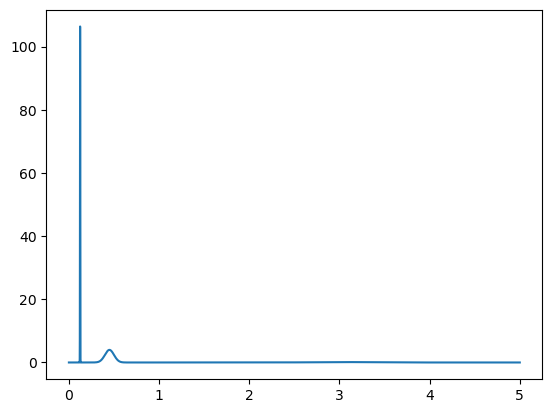

In [3]:
plt.plot(fine_τ_grid, true_τ_distribution)

In [4]:
irf_sigma = np.array([0.250/(2*np.sqrt(2*np.log(2)))])
IRF = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

In [5]:
lt_model = LifetimeModel("simulation", lifetimes=fine_τ_grid, intensities=true_τ_distribution)
time_step = 5e-3 # 5 picosecond
time = np.arange(-2, 40, time_step)
bg_frac = 0.1

expected_background = bg_frac/(time[-1]-time[0]) * np.ones_like(time)
analytical_spectrum = generate_analytical_lt_spectrum(time, lt_model, IRF, bg_frac)
random_spectrum = generate_random_lt_spectrum(time, lt_model, IRF, bg_frac, int(1e7))

In [6]:
# resolution function using response to impulse
impulse = np.zeros_like(time)
impulse[np.where(time>0)[0][0]] = 1/(time[1] - time[0])

res_fun = IRF.convolve(impulse,time)

(-1.0, 20.0)

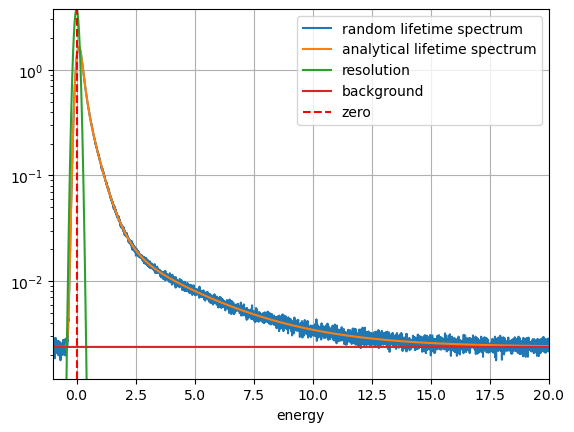

In [10]:
random_normalizer = random_spectrum.lifetime.integrate('energy')
(random_spectrum.lifetime/random_normalizer).plot(label='random lifetime spectrum', yscale='log')
analytical_spectrum.lifetime.plot(label='analytical lifetime spectrum', yscale='log')

plt.plot(time, res_fun, label='resolution')
plt.plot(time, expected_background, label='background')
plt.axvline(0, color='red', label='zero', ls='--')
plt.legend()
plt.ylim([expected_background[0]/2, np.max([res_fun.max(), analytical_spectrum.lifetime.max()])])
plt.grid()
plt.xlim([-1, 20])

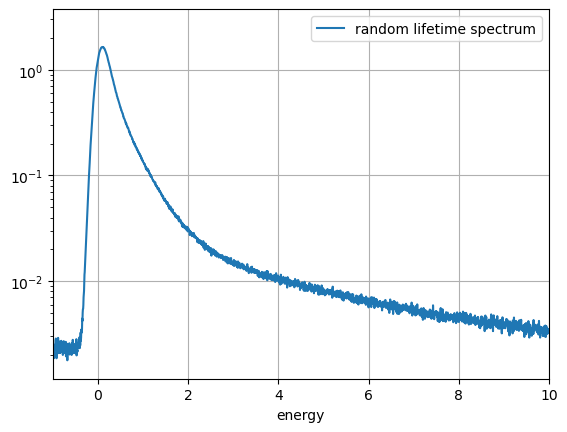

In [9]:
random_normalizer = random_spectrum.lifetime.integrate('energy')
(random_spectrum.lifetime/random_normalizer).plot(label='random lifetime spectrum', yscale='log')
plt.plot()
plt.legend()
plt.xlim(-1,10)
plt.ylim([expected_background[0]/2, np.max([res_fun.max(), analytical_spectrum.lifetime.max()])])
plt.grid()

# Inversion

In [11]:
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix
from matplotlib.colors import LogNorm
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.tikhonov import TikhonovRegularization

In [12]:
dτ = 2.5e-2
τ_grid = np.arange(dτ, 5, dτ)

dt = 5e-3
time_grid = np.arange(-2, 40, dt)

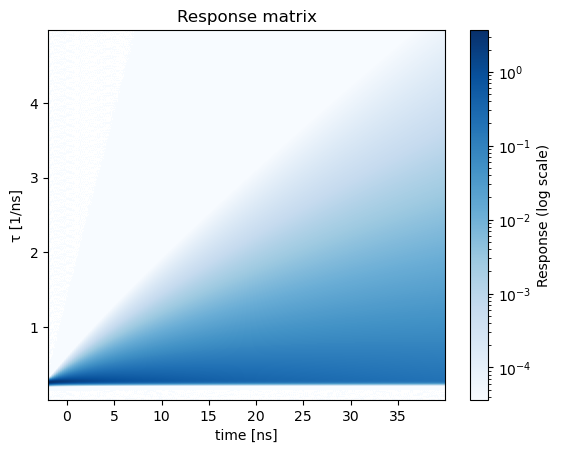

In [13]:
RM = _response_matrix(τ_grid, time_grid, IRF)
vmax = RM.max()
vmin = vmax / 1e5   # 5 orders of magnitude

plt.imshow(RM,
           cmap='Blues',
           origin='lower',
           extent=[time.min(), time.max(),
                   τ_grid.min(), τ_grid.max()],
           aspect='auto',
           norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(label='Response (log scale)')
plt.title('Response matrix')
plt.xlabel('time [ns]')
plt.ylabel('τ [1/ns]')
plt.show()

In [79]:
import numpy as np
import xarray as xr
from scipy.optimize import nnls, minimize
from pyPAS.core.lt import PASLifetime
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix, _svd_truncate


class TikhonovRegularization(LifetimeInvert):
    """
    Inverts a positron lifetime spectrum into a lifetime distribution q(τ)
    using Tikhonov regularization with automatic alpha selection.

    The inversion solves:
        min ||R@q - s||^2 + α||D^2@q||^2,  q >= 0

    where R is the response matrix, s is the normalized spectrum,
    D^2 is the second-order finite difference operator (penalizes curvature),
    and α controls the smoothness tradeoff.

    Alpha is selected automatically by minimizing the chi-squared residual
    between the forward model and the data, searched in log space.
    """

    def _tikhonov_solution(self,
                           normlized_pals: np.ndarray,
                           response: np.ndarray,
                           alpha: float,
                           maxiter=None) -> np.ndarray:
        """
        Solve the regularized inversion for a fixed alpha via augmented NNLS.

        The response matrix approximates the continuous integral ∫ R(t,τ) q(τ) dτ,
        making q a true probability density over τ rather than a per-bin weight.

        The augmented system is:
            [R·dτ        ] q = [s]
            [√α · D²     ]     [0]
        (first equation is the optimization and the second is the penalty)

        Parameters
        ----------
        normlized_pals : np.ndarray
            Measured spectrum normalized to unit integral.
        response : np.ndarray
            Response matrix of shape (n_time, n_tau).
        alpha : float
            Regularization strength.
        maxiter : int, optional
            Max iterations for NNLS solver.

        Returns
        -------
        q : np.ndarray
            Lifetime distribution over the characteristic time grid.
        """
        n_tau = len(self.characteristic_time_grid)
        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]

        D2 = (np.eye(n_tau, k=0) - 2 * np.eye(n_tau, k=1) + np.eye(n_tau, k=2))[:n_tau - 2]

        A_aug = np.vstack([response * dtau, np.sqrt(alpha) * D2])
        b_aug = np.concatenate([normlized_pals, np.zeros(n_tau - 2)])

        q, _ = nnls(A_aug, b_aug, maxiter=maxiter)
        return q

    def chi_sq_log(self, log_alpha, pals, response, maxiter, error=True) -> float:
        """
        Chi-squared residual between forward model and data, as a function of log(α).

        Optimized in log space so alpha stays positive and spans orders of magnitude
        naturally. If error=True, residuals are weighted by Poisson uncertainties.

        Parameters
        ----------
        log_alpha : array-like of length 1
            Log of the regularization parameter.
        pals : PASLifetime
            Measured lifetime spectrum.
        response : np.ndarray
            Response matrix.
        maxiter : int
            Max NNLS iterations.
        error : bool
            If True, use Poisson-weighted chi-squared. Default True.

        Returns
        -------
        float
            Sum of (weighted) squared residuals.
        """
        alpha = float(np.exp(log_alpha[0]))
        alpha = np.clip(alpha, 1e-12, 1e-1)

        counts = pals.lifetime.counts
        time = pals.lifetime.energy.values
        norm = pals.lifetime.integrate('energy').item()
        normlized_pals = counts / norm

        if error:
            normlized_pals_err = np.sqrt(np.maximum(counts, 1)) / norm

        q = self._tikhonov_solution(
            normlized_pals=normlized_pals,
            response=response,
            alpha=alpha,
            maxiter=maxiter
        )

        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]
        lifetime_q = response @ q * dtau


        if error:
            chi_sq = (normlized_pals - lifetime_q) ** 2 / normlized_pals_err ** 2
        else:
            chi_sq = (normlized_pals - lifetime_q) ** 2

        return np.abs(np.sum(chi_sq)/len(counts)-1)

    def invert(self, pals: PASLifetime,
               maxiter=None,
               initial_alpha=None,
               method="Powell",
               regulator_bounds=(1e-10, 1e-1),
               minimization_ftol=1e-6,
               error: bool = True,
               svd_truncate: float = None) -> tuple[np.ndarray, object]:
        """
        Invert a lifetime spectrum into a lifetime distribution q(τ).

        Automatically selects the regularization parameter α by minimizing
        the chi-squared residual in log space, then returns the final q(τ)
        at the optimal α.

        Parameters
        ----------
        pals : PASLifetime
            Measured lifetime spectrum with associated resolution function.
        maxiter : int, optional
            Max NNLS iterations. Defaults to 10 * n_tau.
        initial_alpha : float, optional
            Starting alpha for the optimizer. Defaults to 1e-5.
        method : str
            Scipy minimize method. Default "Powell".
        regulator_bounds : tuple
            (min, max) bounds for alpha search. Default (1e-10, 1e-1).
        minimization_ftol : float
            Convergence tolerance for the optimizer. Default 1e-6.
        error : bool
            If True, use Poisson-weighted chi-squared. Default True.
        Returns
        -------
        q : np.ndarray
            Recovered lifetime distribution over characteristic_time_grid.
        res : OptimizeResult
            Full scipy optimization result, including optimal alpha via np.exp(res.x[0]).
        """
        if maxiter is None:
            maxiter = 10 * self.characteristic_time_grid.shape[0]
        if initial_alpha is None:
            initial_alpha = 1e-5

        response = _response_matrix(
            self.characteristic_time_grid,
            pals.lifetime.energy.values,
            pals.resolution
        )
        if svd_truncate is not None:
            Up, sp, Vtp = _svd_truncate(response, svd_truncate)
            response = Up @ np.diag(sp) @ Vtp



        res = minimize(
            self.chi_sq_log,
            x0=[np.log(initial_alpha)],
            args=(pals, response, maxiter, error),
            bounds=[(np.log(regulator_bounds[0]), np.log(regulator_bounds[1]))],
            method=method,
            options={"ftol": minimization_ftol}
        )

        alpha_opt = float(np.exp(res.x[0]))

        norm = pals.lifetime.integrate('energy').item()
        normlized_pals = pals.lifetime.counts / norm

        q = self._tikhonov_solution(
            normlized_pals=normlized_pals,
            response=response,
            alpha=alpha_opt,
            maxiter=maxiter
        )

        return q, res

In [80]:
tinvert = TikhonovRegularization(random_spectrum.lifetime.energy.values, τ_grid)
q, res = tinvert.invert(random_spectrum, initial_alpha=1e-5, error=True)

In [18]:
tinvert = TikhonovRegularization(random_spectrum.lifetime.energy.values, τ_grid)
q, res = tinvert.invert(random_spectrum, initial_alpha=1e-5, error=True, background_value=random_spectrum.lifetime.counts[-1000:].mean())

In [81]:
# the resulted optimization gives gives integral of 1 as expected
np.trapz(q, τ_grid), res

(1.0040132254392111,
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.728971553906437
        x: [-1.017e+01]
      nit: 1
    direc: [[ 1.000e+00]]
     nfev: 28)

In [20]:
q[40:].sum()/q.sum()

0.09488792061394018

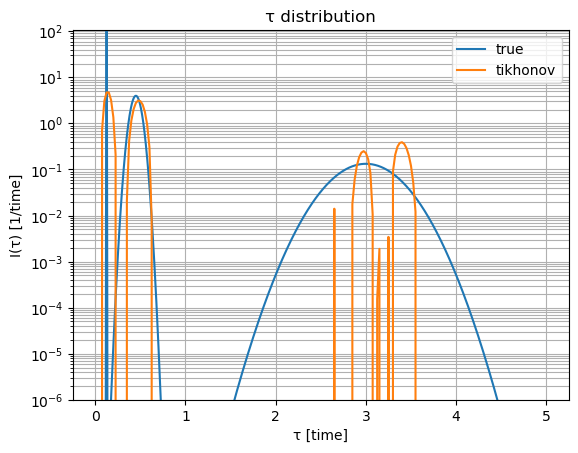

In [19]:
plt.plot(fine_τ_grid, true_τ_distribution, label="true")
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.yscale("log")
plt.ylim([1e-6, true_τ_distribution.max()])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()

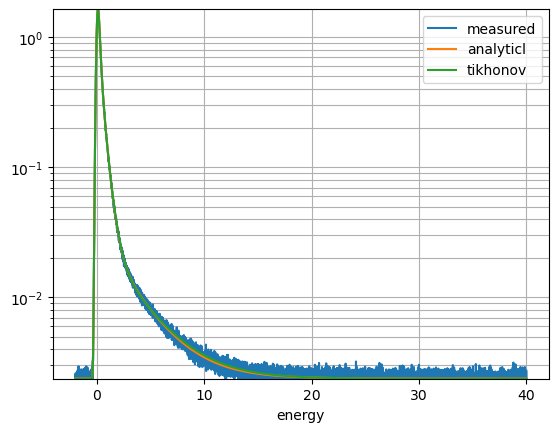

In [27]:
tikhonov_result_model = LifetimeModel('', τ_grid, q/np.trapz(q,τ_grid))
tikhonov_lifetime = generate_analytical_lt_spectrum(time,
                                                    tikhonov_result_model,
                                                    resolution=IRF,
                                                    background_fraction=0)
tikhonov_lifetime.lifetime.counts *= np.trapz(q, τ_grid)
tikhonov_lifetime.lifetime.counts += random_spectrum.lifetime.counts[-1000:].mean()
(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='measured')
(analytical_spectrum.lifetime/analytical_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='analyticl')
(tikhonov_lifetime.lifetime/tikhonov_lifetime.lifetime.integrate('energy')).plot(yscale='log', label='tikhonov')

plt.grid(which="both")

plt.ylim([random_spectrum.lifetime.counts[-1000:].mean()/random_spectrum.lifetime.integrate('energy'),(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).max()])
plt.legend()

In [ ]:
import numpy as np
from scipy.optimize import minimize, brentq
from pyPAS.core.lt import PASLifetime
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix, _svd_truncate


class MaximalEntropyInversion(LifetimeInvert):
    """
    Inverts a positron lifetime spectrum into a lifetime distribution f(τ)
    using the Maximum Entropy Method (MELT), following Bryan (1990).

    The algorithm maximizes:
        Q(f, α) = α·S(f) - L(f)

    where:
        S(f) = Σ (fᵢ - mᵢ - fᵢ log(fᵢ/mᵢ))  is the entropy relative to prior m
        L(f) = ½ Σ (F_k - D_k)² / σ_k²        is the negative log likelihood (chi2/2)
        α                                        is the regularization parameter

    The key insight from Bryan (1990) is that at the maximum of Q, log(f/m) must
    lie in the column space of U (the right singular vectors of T in tau space).
    This means f can be parameterized as:
        fᵢ = mᵢ · exp(Σ_t U_{it} · u_t)

    where u is an s-dimensional vector (s = rank(T) << N_tau). This reduces the
    optimization from N_tau variables to s variables, and automatically keeps f positive.

    The regularization parameter α is determined automatically by the Bayesian
    evidence criterion (equation 19 in Bryan 1990):
        Σᵢ λᵢ/(α + λᵢ) = -2α·S(f̂)

    where λᵢ are eigenvalues of Ks @ Ms (defined in section 2.1 of the paper).

    Convention note: Bryan (1990) writes T = V Σ Uᵀ where U is in tau space
    and V is in time space. This is the OPPOSITE of numpy's SVD convention
    (numpy gives T = U Σ Vᵀ). In this implementation we follow the paper's
    convention: U is in tau space, V is in time space.

    References
    ----------
    Bryan, R.K. (1990). Solving oversampled data problems by maximum entropy.
    In: Maximum Entropy and Bayesian Methods, pp. 221-232.
    """

    # -------------------------------------------------------------------------
    # Section 1: Core quantities — entropy, likelihood, and Q
    # -------------------------------------------------------------------------

    def _entropy(self, f: np.ndarray, prior: np.ndarray) -> float:
        """
        Relative Shannon entropy of f with respect to prior model m.
        This is the entropy as defined in Bryan (1990) equation in section 1:

            S(f) = Σᵢ (fᵢ - mᵢ - fᵢ log(fᵢ/mᵢ))

        Note: S(f) <= 0, with S(f) = 0 only when f = m exactly.
        The entropy penalizes deviation from the prior m.

        Parameters
        ----------
        f : np.ndarray (N_tau,)
            Current lifetime distribution (must be positive).
        prior : np.ndarray (N_tau,)
            Prior default model over tau grid. Flat if no prior knowledge.

        Returns
        -------
        float
            Entropy value (<=0, equals 0 when f == m).
        """
        f_safe = np.clip(f, 1e-30, None)
        return np.sum(f_safe - prior - f_safe * np.log(f_safe / prior))

    def _likelihood(self,
                    f: np.ndarray,
                    V: np.ndarray,
                    sigma: np.ndarray,
                    Ut: np.ndarray,
                    data: np.ndarray,
                    data_err: np.ndarray) -> float:
        """
        Negative log likelihood L(f), which for Gaussian noise is chi2/2:

            L(f) = ½ Σ_k (F_k - D_k)² / σ_k²

        where F = Tf is computed efficiently using the truncated SVD:
            F = V @ diag(sigma) @ Ut @ f

        Parameters
        ----------
        f : np.ndarray (N_tau,)
            Current lifetime distribution.
        V : np.ndarray (N_time x s)
            Left singular vectors in time space (paper's V).
        sigma : np.ndarray (s,)
            Truncated singular values.
        Ut : np.ndarray (s x N_tau)
            Transposed right singular vectors in tau space (paper's Uᵀ).
        data : np.ndarray (N_time,)
            Normalized measured spectrum D.
        data_err : np.ndarray (N_time,)
            Uncertainties σ_k on data.

        Returns
        -------
        float
            L(f) = chi2/2.
        """
        F = V @ (sigma * (Ut @ f))  # T @ f via SVD, shape (N_time,)
        mask = data > 0
        residuals = (data[mask] - F[mask]) ** 2
        return 0.5 * np.sum(residuals / data_err[mask] ** 2)

    def _Q(self,
           f: np.ndarray,
           alpha: float,
           prior: np.ndarray,
           V: np.ndarray,
           sigma: np.ndarray,
           Ut: np.ndarray,
           data: np.ndarray,
           data_err: np.ndarray) -> float:
        """
        The objective function Q = α·S(f) - L(f) to be maximized.

        Parameters
        ----------
        f : np.ndarray (N_tau,)
            Current lifetime distribution.
        alpha : float
            Regularization parameter balancing entropy vs data fit.
        prior : np.ndarray (N_tau,)
            Prior default model.
        V, sigma, Ut : np.ndarray
            Truncated SVD components (paper convention).
        data : np.ndarray (N_time,)
            Normalized measured spectrum.
        data_err : np.ndarray (N_time,)
            Data uncertainties.

        Returns
        -------
        float
            Q value (to be maximized).
        """
        S = self._entropy(f, prior)
        L = self._likelihood(f, V, sigma, Ut, data, data_err)
        return alpha * S - L

    # -------------------------------------------------------------------------
    # Section 2: Optimization of f at fixed alpha
    # -------------------------------------------------------------------------

    def _f_from_u(self,
                  u: np.ndarray,
                  prior: np.ndarray,
                  U: np.ndarray) -> np.ndarray:
        """
        Reconstruct f from the s-dimensional singular space vector u.
        This is equation (9) from Bryan (1990):

            fᵢ = mᵢ · exp(Σ_t U_{it} · u_t)

        This parameterization:
        1. Keeps f strictly positive (exp is always positive)
        2. Restricts f to the subspace visible to the data (column space of U)
        3. Reduces optimization from N_tau to s variables

        Parameters
        ----------
        u : np.ndarray (s,)
            Optimization variable in singular space.
        prior : np.ndarray (N_tau,)
            Prior default model m.
        U : np.ndarray (N_tau x s)
            Right singular vectors in tau space (paper's U).

        Returns
        -------
        np.ndarray (N_tau,)
            Lifetime distribution f.
        """
        return prior * np.exp(U @ u)

    def _optimize_f(self,
                    alpha: float,
                    prior: np.ndarray,
                    U: np.ndarray,
                    V: np.ndarray,
                    sigma: np.ndarray,
                    Ut: np.ndarray,
                    data: np.ndarray,
                    data_err: np.ndarray,
                    u0: np.ndarray) -> np.ndarray:
        """
        Maximize Q over u at fixed alpha using scipy (equivalent to Newton
        method of Bryan 1990 section 2.2, but using scipy for simplicity
        since our s is small ~10-20).

        Parameters
        ----------
        alpha : float
            Fixed regularization parameter.
        prior : np.ndarray (N_tau,)
            Prior default model.
        U : np.ndarray (N_tau x s)
            Right singular vectors in tau space.
        V, sigma, Ut : np.ndarray
            Truncated SVD components.
        data : np.ndarray (N_time,)
            Normalized measured spectrum.
        data_err : np.ndarray (N_time,)
            Data uncertainties.
        u0 : np.ndarray (s,)
            Initial guess for u.

        Returns
        -------
        np.ndarray (N_tau,)
            Optimal f̂ at given alpha.
        """
        def neg_Q(u):
            f = self._f_from_u(u, prior, U)
            return -self._Q(f, alpha, prior, V, sigma, Ut, data, data_err)

        result = minimize(neg_Q, u0, method='L-BFGS-B')
        return self._f_from_u(result.x, prior, U), result.x

    # -------------------------------------------------------------------------
    # Section 3: Eigenvalue computation and alpha update
    # Following Bryan (1990) section 2.1 and 2.5
    # -------------------------------------------------------------------------

    def _compute_eigenvalues(self, f_hat, U, V, sigma, data_err):
        # Ks = Uᵀ diag{f} U
        Ks = U.T @ np.diag(f_hat) @ U
    
        # mask zero errors
        mask = data_err > 0
        W = np.zeros(len(data_err))
        W[mask] = 1.0 / data_err[mask] ** 2
    
        # Ms = Σ Vᵀ diag{W} V Σ
        Ms = (sigma[:, None] * V.T) * W @ (V * sigma[None, :])
    
        # use eig instead of eigvalsh since Ks @ Ms is not symmetric
        eigenvalues = np.real(np.linalg.eig(Ks @ Ms)[0])
        return np.clip(eigenvalues, 0, None)

    def _update_alpha(self,
                      f_hat: np.ndarray,
                      eigenvalues: np.ndarray,
                      alpha_bounds: tuple) -> float:
        """
        Find optimal alpha by solving equation (19) from Bryan (1990):

            Σᵢ λᵢ/(α + λᵢ) = -2α·S(f̂)

        The left side counts the number of "good" observations (eigenvalues
        significantly larger than α contribute ~1 each). The right side is
        determined by the entropy of the current solution.

        This is solved numerically using brentq since both sides depend on α.

        Parameters
        ----------
        f_hat : np.ndarray (N_tau,)
            Current optimal f.
        eigenvalues : np.ndarray (s,)
            Eigenvalues λᵢ from _compute_eigenvalues.
        alpha_bounds : tuple
            (alpha_min, alpha_max) for brentq search.

        Returns
        -------
        float
            Updated optimal alpha.
        """
        S_hat = self._entropy(f_hat, self._prior)

        def alpha_equation(alpha):
            lhs = np.sum(eigenvalues / (alpha + eigenvalues))
            rhs = -2 * alpha * S_hat
            return lhs - rhs

        try:
            alpha_new = brentq(alpha_equation, alpha_bounds[0], alpha_bounds[1])
        except ValueError:
            # if brentq fails (no sign change), keep current alpha
            alpha_new = self._current_alpha

        return alpha_new

    # -------------------------------------------------------------------------
    # Section 4: Main optimization loop
    # -------------------------------------------------------------------------

    def _optimize(self,
                  U: np.ndarray,
                  V: np.ndarray,
                  sigma: np.ndarray,
                  Ut: np.ndarray,
                  data: np.ndarray,
                  data_err: np.ndarray,
                  alpha_bounds: tuple,
                  ftol: float,
                  maxiter: int) -> tuple:
        """
        Main MELT optimization loop. Iterates between:
        1. Optimizing f at fixed alpha (section 2.2 of Bryan 1990)
        2. Updating alpha given current f (section 2.5 of Bryan 1990)

        Until convergence of alpha.

        Parameters
        ----------
        U : np.ndarray (N_tau x s)
            Right singular vectors in tau space (paper's U).
        V : np.ndarray (N_time x s)
            Left singular vectors in time space (paper's V).
        sigma : np.ndarray (s,)
            Truncated singular values.
        Ut : np.ndarray (s x N_tau)
            Transposed U.
        data : np.ndarray (N_time,)
            Normalized measured spectrum.
        data_err : np.ndarray (N_time,)
            Data uncertainties.
        alpha_bounds : tuple
            (alpha_min, alpha_max) for alpha search.
        ftol : float
            Convergence tolerance on relative change of alpha.
        maxiter : int
            Maximum number of outer iterations.

        Returns
        -------
        tuple (alpha, f_hat)
            Optimal regularization parameter and lifetime distribution.
        """
        # initialize
#        alpha = self._current_alpha
        u = np.zeros(len(sigma))  # start at f = prior (u=0 -> exp(0)=1)
            
        def optimize_logalpha(log_alpha):
            nonlocal u  # reuse u as warm start between calls
            alpha = np.exp(log_alpha)
            
            fhat, u_new = self._optimize_f(alpha, self._prior, U, V, sigma, Ut, data, data_err, u)
            u = u_new  # warm start for next call
            return -self._Q(fhat, alpha, self._prior, V, sigma, Ut, data, data_err)
                
        result  = minimize(optimize_logalpha, 
                                x0=np.log(self._current_alpha),
                                method='Powell',
                                options={"ftol": ftol, "maxiter":maxiter},
                               )
        alpha_opt = np.exp(result.x.item())
        f_hat, _ = self._optimize_f(
                alpha_opt, self._prior, U, V, sigma, Ut, data, data_err, u
            )
#        for iteration in range(maxiter):
#            # Step 1: optimize f at fixed alpha (s-dimensional optimization)
#            f_hat, u = self._optimize_f(
#                alpha, self._prior, U, V, sigma, Ut, data, data_err, u
#            )
#
#            # Step 2: compute eigenvalues at current f_hat
#            eigenvalues = self._compute_eigenvalues(f_hat, U, V, sigma, data_err)
#
#            # Step 3: update alpha using equation (19)
#            alpha_new = self._update_alpha(f_hat, eigenvalues, alpha_bounds)
#
#            # check convergence on relative change of alpha
#            rel_change = abs(alpha_new - alpha) / (abs(alpha) + 1e-30)
#            alpha = alpha_new
#            self._current_alpha = alpha
#
#            if rel_change < ftol:
#                break

        return alpha_opt, f_hat

    # -------------------------------------------------------------------------
    # Section 5: Public interface
    # -------------------------------------------------------------------------

    def invert(self,
               pals: PASLifetime,
               maxiter: int = None,
               noise_level: float = 1e-10,
               initial_alpha: float = 1e-5,
               alpha_bounds: tuple = (1e-10, 1e2),
               prior_model: np.ndarray = None,
               minimization_ftol: float = 1e-6) -> tuple:
        """
        Invert a positron lifetime spectrum into a lifetime distribution f(τ)
        using the Maximum Entropy Method.

        Parameters
        ----------
        pals : PASLifetime
            Measured lifetime spectrum with resolution function.
        maxiter : int, optional
            Max outer iterations. Defaults to 10 * n_tau.
        noise_level : float
            SVD truncation threshold relative to largest singular value.
            Controls how many singular values are retained (s).
            Default 1e-3.
        initial_alpha : float
            Starting alpha for optimization. Default 1e-3.
        alpha_bounds : tuple
            (min, max) bounds for alpha search. Default (1e-10, 1e2).
        prior_model : np.ndarray, optional
            Prior over tau grid. Defaults to flat (uniform) model.
        minimization_ftol : float
            Convergence tolerance on relative alpha change. Default 1e-6.

        Returns
        -------
        alpha_opt : float
            Optimal regularization parameter found by Bayesian evidence.
        f_hat : np.ndarray (N_tau,)
            Recovered lifetime distribution over characteristic_time_grid.
        """
        # ---- setup ----
        n_tau = len(self.characteristic_time_grid)
        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]

        if maxiter is None:
            maxiter = 10 * n_tau

        # ---- normalize data ----
        counts = pals.lifetime.counts
        norm = pals.lifetime.integrate('energy').item()
        data = counts / norm
        data_err = np.sqrt(counts) / norm

        # ---- build response matrix and compute SVD ----
        # V (N_time x s), sigma (s,), Ut (s x N_tau) in paper convention
        response = _response_matrix(
            self.characteristic_time_grid,
            pals.lifetime.energy.values,
            pals.resolution
        )
        V, sigma, Ut = _svd_truncate(response * dtau, noise_level)
        U = Ut.T  # (N_tau x s) — paper's U, tau space

        # ---- set prior ----
        if prior_model is None:
            prior_model = np.ones(n_tau) / n_tau  # flat prior
        self._prior = prior_model

        # ---- initialize alpha ----
        self._current_alpha = initial_alpha

        # ---- run optimization ----
        alpha_opt, f_hat = self._optimize(
            U=U,
            V=V,
            sigma=sigma,
            Ut=Ut,
            data=data,
            data_err=data_err,
            alpha_bounds=alpha_bounds,
            ftol=minimization_ftol,
            maxiter=maxiter
        )

        return alpha_opt, f_hat

In [17]:
random_spectrum.lifetime.counts = np.abs(random_spectrum.lifetime.counts - random_spectrum.lifetime.counts[-100:].mean().item())

In [18]:
random_spectrum.lifetime.counts[-100:].mean().item()

9.3496

In [19]:
type(random_spectrum.lifetime)

pyspectrum.spectrum.spectrum.Spectrum

In [20]:
melt = MaximalEntropyInversion(random_spectrum.lifetime.energy.values, τ_grid)

In [21]:
a1, melt_q1 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-3)

In [22]:
a2, melt_q2 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-5)

In [23]:
a1

1.8769264412015166e-09

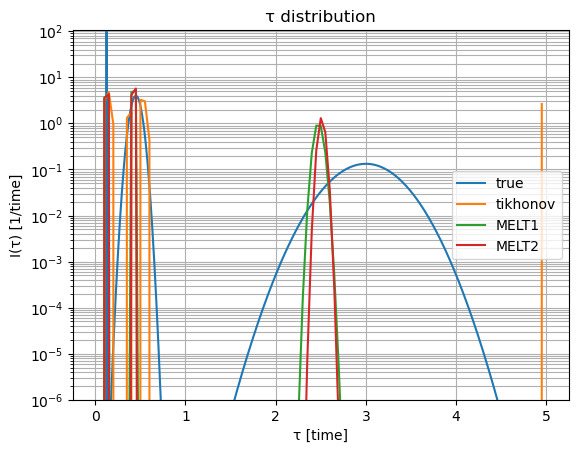

In [24]:
plt.plot(fine_τ_grid, true_τ_distribution, label="true")
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.plot(τ_grid, melt_q1/np.trapz(melt_q1,τ_grid), label='MELT1')
plt.plot(τ_grid, melt_q2/np.trapz(melt_q2,τ_grid), label='MELT2')

plt.yscale("log")
#plt.xscale("log")

plt.ylim([1e-6, true_τ_distribution.max()])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()
plt.show()

In [25]:
np.trapz(melt_q2, x=τ_grid)

0.897268254441278

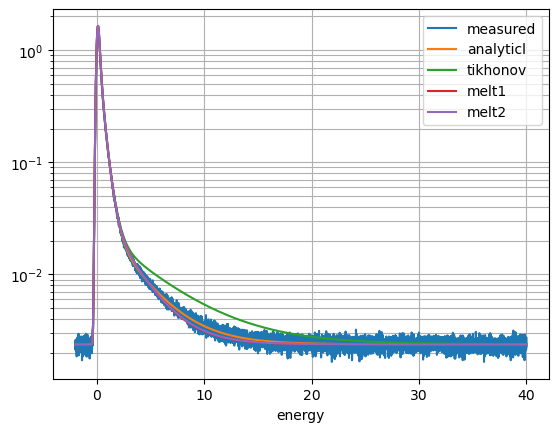

In [26]:
melt_result_model1 = LifetimeModel('', τ_grid, melt_q1/np.trapz(melt_q1,τ_grid))
melt_result_model2 = LifetimeModel('', τ_grid, melt_q2/np.trapz(melt_q2,τ_grid))

melt_lifetime1 = generate_analytical_lt_spectrum(time,
                                                    melt_result_model1,
                                                    resolution=IRF,
                                                    background_fraction=bg_frac)
melt_lifetime2 = generate_analytical_lt_spectrum(time,
                                                    melt_result_model2,
                                                    resolution=IRF,
                                                    background_fraction=bg_frac)
(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='measured')
(analytical_spectrum.lifetime/analytical_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='analyticl')
tikhonov_lifetime.lifetime.plot(label='tikhonov')
melt_lifetime1.lifetime.plot(label='melt1')
melt_lifetime2.lifetime.plot(label='melt2')
plt.grid(which="both")


plt.legend()

In [30]:
(((random_spectrum.lifetime.counts - melt_lifetime2.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

0.5335076440770519

In [31]:
(((random_spectrum.lifetime.counts - melt_lifetime1.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

0.5335071004358116

In [54]:
eg = 170
em = 511
t = np.pi

eg - eg/(1+eg/em*(1-np.cos(t)))

67.92009400705052

In [ ]:
import numpy as np
import xarray as xr
from scipy.optimize import minimize, nnls
from pyPAS.core.lt import PASLifetime
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix, _svd_truncate

class MELTInversion(LifetimeInvert):
    """
    Inverts a positron lifetime spectrum into a lifetime distribution q(τ)
    using the Maximum Entropy method (MELT).

    The inversion maximizes:
        S(q) - α · χ²(q)

    where S(q) = -Σ qᵢ log(qᵢ/mᵢ) is the relative entropy with respect to
    a default model m, and χ² measures fit quality. α is determined
    automatically within the Bayesian framework.

    The response matrix is first cleaned via SVD truncation — singular values
    below the noise threshold are discarded, removing noise-dominated directions
    before the MaxEnt optimization.
    """


    def _entropy(self, q: np.ndarray, prior_model: np.ndarray) -> float:
        """
        Relative Shannon entropy of q with respect to default model m.

            S(q) = -Σ qᵢ log(qᵢ / mᵢ)

        Parameters
        ----------
        q : np.ndarray
            Current lifetime distribution (must be positive).
        prior_model : np.ndarray
            Prior default model over tau grid. Flat if no prior knowledge.

        Returns
        -------
        float
            Entropy value (positive when q ≈ m).
        """
        q_safe = np.clip(q, 1e-30, None)
        return -np.sum(q_safe * np.log(q_safe / prior_model))

    def _chi_sq(self,
                q: np.ndarray,
                U: np.ndarray,
                s: np.ndarray,
                Vt: np.ndarray,
                normlized_pals: np.ndarray,
                normlized_pals_err: np.ndarray) -> float:
        """
        Chi-squared residual in the truncated SVD space.

        Parameters
        ----------
        q : np.ndarray
            Current lifetime distribution.
        U, s, Vt : np.ndarray
            Truncated SVD components of the scaled response matrix.
        normlized_pals : np.ndarray
            Normalized measured spectrum.
        normlized_pals_err : np.ndarray
            Poisson uncertainty on normalized spectrum.

        Returns
        -------
        float
            Chi-squared value.
        """
        lifetime_q = U @ (s * (Vt @ q))  # = response_clean @ q
        mask = normlized_pals > 0
        residuals = (normlized_pals[mask] - lifetime_q[mask]) ** 2
        return np.sum(residuals / normlized_pals_err[mask] ** 2)

    def _melt_objective(self,
                        log_q: np.ndarray,
                        alpha: float,
                        U: np.ndarray,
                        s: np.ndarray,
                        Vt: np.ndarray,
                        normlized_pals: np.ndarray,
                        normlized_pals_err: np.ndarray,
                        default_model: np.ndarray) -> float:
        """
        MELT objective function: α·χ²(q) - S(q), minimized over log(q).

        Parameterized in log space to enforce q > 0 without constraints.

        Parameters
        ----------
        log_q : np.ndarray
            Log of the lifetime distribution (optimization variable).
        alpha : float
            Entropy weight — balances fit fidelity against entropy.
        U, s, Vt : np.ndarray
            Truncated SVD components.
        normlized_pals : np.ndarray
            Normalized measured spectrum.
        normlized_pals_err : np.ndarray
            Poisson uncertainty.
        default_model : np.ndarray
            Prior default model for entropy calculation.

        Returns
        -------
        float
            Objective value.
        """
        q = np.exp(log_q)
        chi2 = self._chi_sq(q, U, s, Vt, normlized_pals, normlized_pals_err)
        entropy = self._entropy(q, default_model)
        return alpha * chi2 - entropy

    def _find_alpha(self,
                    log_q: np.ndarray,
                    U: np.ndarray,
                    s: np.ndarray,
                    Vt: np.ndarray,
                    normlized_pals: np.ndarray,
                    normlized_pals_err: np.ndarray,
                    default_model: np.ndarray,
                    n_good: int,
                    alpha_bounds: tuple,
                    ftol: float) -> float:
        """
        Determine optimal alpha by matching χ² ≈ n_good (number of
        retained singular values) — the Bayesian evidence criterion.

        Parameters
        ----------
        log_q : np.ndarray
            Current log distribution (warm start).
        n_good : int
            Number of retained singular values — target for χ².
        alpha_bounds : tuple
            (min, max) bounds for alpha search.
        ftol : float
            Convergence tolerance.

        Returns
        -------
        float
            Optimal alpha.
        """
        def chi_sq_gap(log_alpha):
            alpha = float(np.exp(log_alpha[0]))
            res = minimize(
                self._melt_objective,
                x0=log_q,
                args=(alpha, U, s, Vt, normlized_pals, normlized_pals_err, default_model),
                method="L-BFGS-B",
                options={"ftol": ftol, "maxiter":100}
            )
            q = np.exp(res.x)
            chi2 = self._chi_sq(q, U, s, Vt, normlized_pals, normlized_pals_err)
            return (chi2 - n_good) ** 2  # drive χ² → n_good

        res = minimize(
            chi_sq_gap,
            x0=[np.log(1e-3)],
            bounds=[(np.log(alpha_bounds[0]), np.log(alpha_bounds[1]))],
            method="Powell",
            options={"ftol": ftol, "maxiter":100},
            
        )
        return float(np.exp(res.x[0]))

    def invert(self,
               pals: PASLifetime,
               maxiter=None,
               noise_level=1e-10,
               initial_alpha=1e-3,
               alpha_bounds=(1e-10, 1e2),
               prior_model=None,
               minimization_ftol=1e-6) -> tuple[np.ndarray, object]:
        """
        Invert a lifetime spectrum into a lifetime distribution q(τ) via MELT.

        Parameters
        ----------
        pals : PASLifetime
            Measured lifetime spectrum with resolution function.
        maxiter : int, optional
            Max iterations for inner optimizer. Defaults to 10 * n_tau.
        noise_level : float
            SVD truncation threshold relative to largest singular value.
            Default 1e-3.
        initial_alpha : float
            Starting alpha for Bayesian evidence search. Default 1e-3.
        alpha_bounds : tuple
            (min, max) bounds for alpha. Default (1e-10, 1e2).
        prior_model : np.ndarray, optional
            Prior over tau grid. Defaults to flat (uniform) model.
        minimization_ftol : float
            Convergence tolerance. Default 1e-6.

        Returns
        -------
        q : np.ndarray
            Recovered lifetime distribution over characteristic_time_grid.
        res : OptimizeResult
            Final scipy optimization result.
        """
        if maxiter is None:
            maxiter = 10 * self.characteristic_time_grid.shape[0]

        n_tau = len(self.characteristic_time_grid)
        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]

        if prior_model is None:
            prior_model = np.ones(n_tau) / (self.characteristic_time_grid[-1] - self.characteristic_time_grid[0])  # flat prior

        # ---- normalize data ----
        counts = pals.lifetime.counts
        norm = pals.lifetime.integrate('energy').item()
        normlized_pals = counts / norm
        normlized_pals_err = np.sqrt(counts) / norm

        # ---- build and clean response matrix ----
        response = _response_matrix(
            self.characteristic_time_grid,
            pals.lifetime.energy.values,
            pals.resolution
        )
        U, s, Vt = _svd_truncate(response * dtau, noise_level)
        n_good = len(s)  # number of retained singular values

        # ---- find optimal alpha ----
        log_q0 = np.log(default_model)
        alpha_opt = self._find_alpha(
            log_q=log_q0,
            U=U, s=s, Vt=Vt,
            normlized_pals=normlized_pals,
            normlized_pals_err=normlized_pals_err,
            default_model=default_model,
            n_good=n_good,
            alpha_bounds=alpha_bounds,
            ftol=minimization_ftol
        )

        # ---- final solution at optimal alpha ----
        res = minimize(
            self._melt_objective,
            x0=log_q0,
            args=(alpha_opt, U, s, Vt, normlized_pals, normlized_pals_err, default_model),
            method="L-BFGS-B",
            options={"ftol": minimization_ftol, "maxiter": maxiter}
        )

        q = np.exp(res.x)
        return q, res